<a href="https://colab.research.google.com/github/DianaBarradasSanchez/EDPI/blob/main/Prueba_de_frecuencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import tabulate

datos = [0.78961,0.05230,0.76086,0.12079,0.10699,0.55877,0.14151,0.80548,0.82654,0.27738,
         0.65726,0.29453,0.20852,0.79269,0.89898,0.98611,0.57880,0.84488,0.42989,0.34358,
         0.28269,0.67621,0.05010,0.00121,0.38618,0.78059,0.76910,0.70119,0.18284,0.49962,
         0.79982,0.45679,0.68334,0.55170,0.58962,0.21691,0.10859,0.33216,0.87616,0.69623,
         0.03185,0.17028,0.61168,0.55743,0.05475,0.09264,0.29931,0.80861,0.91512,0.57410,
         0.83358,0.76262,0.26593,0.51781,0.85903,0.03272,0.24000,0.65559,0.43308,0.38507,
         0.35286,0.88809,0.90829,0.54325,0.81772,0.94187,0.36982,0.19904,0.58244,0.62400,
         0.09133,0.85853,0.41678,0.88752,0.33954,0.23949,0.19962,0.53559,0.33729,0.33381,
         0.15506,0.65002,0.49383,0.75103,0.19147,0.74579,0.40644,0.79113,0.08128,0.63453,
         0.22287,0.07281,0.73435,0.64183,0.22724,0.44267,0.72102,0.57884,0.87855,0.78545]

Necesitamos una tabla que nos muestre las frecuencias observadas y esperadas, el calculo del estadistico de prueba de Chi cuadrada, definido como: $$\chi^{2*}=\frac{(F_o-F_e)^2}{F_e}$$

In [11]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
inter = ['(0, 0.2]', '(0.2, 0.4]','(0.4, 0.6]','(0.6, 0.8]','(0.8, 1.01]' ]
esp =[]
for i in range(len(conteos)):
  esp.append(20)
estadistico = []
for i in range(len(conteos)):
  estadistico.append((conteos[i] - esp[i])**2/esp[i])

tabla = [[int(i+1),inter[i], conteos[i], esp[i], estadistico[i] ] for i in range(len(conteos))]
print(tabulate.tabulate(tabla,
               headers=['Intervalo','Intervalos', 'Frecuencia observada', 'Frecuencia Esperada', 'Estadistico'],
               tablefmt='grid', numalign='center'))

+-------------+--------------+------------------------+-----------------------+---------------+
|  Intervalo  | Intervalos   |  Frecuencia observada  |  Frecuencia Esperada  |  Estadistico  |
+=============+==============+========================+=======================+===============+
|      1      | (0, 0.2]     |           20           |          20           |       0       |
+-------------+--------------+------------------------+-----------------------+---------------+
|      2      | (0.2, 0.4]   |           20           |          20           |       0       |
+-------------+--------------+------------------------+-----------------------+---------------+
|      3      | (0.4, 0.6]   |           19           |          20           |     0.05      |
+-------------+--------------+------------------------+-----------------------+---------------+
|      4      | (0.6, 0.8]   |           24           |          20           |      0.8      |
+-------------+--------------+----------

Probaremos nuestra prueba de hipotesis para ver si existe diferencia entre la frecuencia observada y la esperada, dada por:\
$H_0$: No hay diferencia entre la frecuencia observada y la frecuencia esperada\
$H_a:$ Existe diferencia


In [12]:
def prueba_frecuencias(datos, bins=None, confianza=0.95):
    n = len(datos)
    if bins is None:
        bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
    k= len(bins)-1
    f_esperada = n / k
    esp = [f_esperada] * k
    estadisticos = []
    for i in range(k):
        valor = ((conteos[i] - esp[i])**2) / esp[i]
        estadisticos.append(valor)
    estadistico_chi= sum(estadisticos)
    alfa = 1 - confianza
    df = k - 1
    chi_critico = stats.chi2.ppf(1 - alfa, df)
    print(f"\nSuma total del estadístico (Chi-test): {estadistico_chi:.5f}")
    print(f"Valor Crítico (Chi-tabla): {chi_critico:.5f}")
    print(f"Grados de libertad: {df}")

    if estadistico_chi <= chi_critico:
        print("Resultado: NO se rechaza H0")
    else:
        print("Resultado: Se rechaza H0")
prueba_frecuencias(datos)


Suma total del estadístico (Chi-test): 1.30000
Valor Crítico (Chi-tabla): 9.48773
Grados de libertad: 4
Resultado: NO se rechaza H0


Finalmente se muestra el grafico de estas diferencias o no.

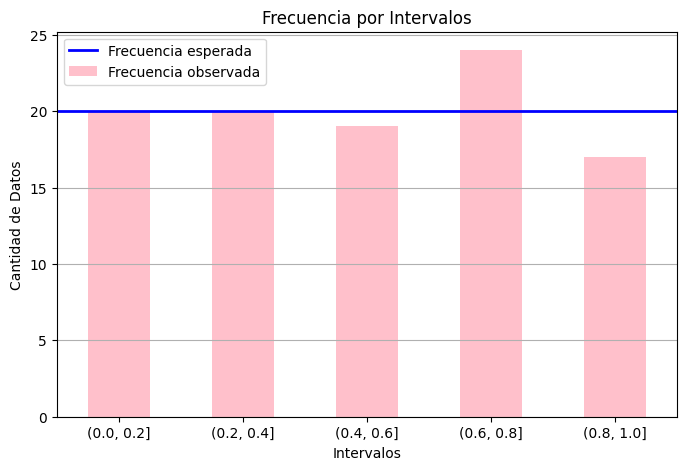

In [13]:
plt.figure(figsize=(8, 5))
frecuencia_obs.plot(kind='bar', color='pink',label="Frecuencia observada")
plt.axhline(y=frecuencia_esp,color="blue",linestyle="-",linewidth=2,label="Frecuencia esperada")
plt.title('Frecuencia por Intervalos')
plt.xlabel('Intervalos')
plt.xticks(rotation=0)
plt.ylabel('Cantidad de Datos')
plt.legend()
plt.grid(axis='y')